# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can historical search performance, content freshness, engagement metrics, and search visibility be combined to identify content pages that should be prioritized for optimization?

## Decision Supported

The objective of this project is to support content optimization decisions by ranking pages according to their observed optimization opportunity. Rather than predicting guaranteed future performance, the model provides a decision-support system that helps prioritize limited optimization resources using historical search intelligence signals.

## Selected Lane

Refresh / Content Opportunity Scoring

## Expected Output

The final output is a ranked list of content pages with an optimization score, recommended action, and reason code explaining why each page was prioritized.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# Dataset

Dataset: content_refresh_anonymized.csv

The dataset contains anonymized search intelligence information collected from historical content performance.

Dataset Summary

- Rows: 30,000
- Columns: 44
- Unit of analysis: one content page
- Dataset type: historical snapshot

Only public-safe variables were used.

Excluded information includes:

- client identities
- domains
- URLs
- private queries
- future outcomes

The dataset is suitable for decision-support analysis rather than causal inference.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print("Shape:", df.shape)

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nPreview")
display(df.head())

Shape: (30000, 44)

Data Types


,0
content_id,object
client_id,object
search_volume,float64
competition,float64
competition_level,object
cpc,float64
content_type,object
main_intent,object
word_count,float64
char_count,float64



Missing Values


,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468



Preview


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# Methodology

## Modeling Objective

The objective of this project is to rank content pages according to their observed optimization opportunity using historical search intelligence signals.

The project does not attempt to predict guaranteed future ranking improvements. Instead, it provides a decision-support system that prioritizes pages for review based on measurable historical evidence.

## Feature Selection

The model uses only information that would have been available before making an optimization decision.

Selected features include:

- search_volume
- competition
- cpc
- word_count
- char_count
- impressions_90d
- clicks_90d
- sessions_90d
- engaged_sessions_90d
- days_since_last_update
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct

Context variables such as content_id are retained only for reporting and are not used for prediction.

## Target Variable

The supervised learning target is trend_pct, which is treated as a continuous proxy for observed content momentum. The model estimates relative optimization opportunity rather than guaranteed future performance.

## Baseline

Before training a machine learning model, a baseline action score was created using manually weighted historical signals.

The baseline combines:

- Search demand
- Search visibility
- Content freshness

The machine learning model is compared against this baseline using the same train-test split.

## Validation Strategy

The dataset is divided into training and testing subsets using an 80/20 split with a fixed random state.

Performance is evaluated on unseen observations.

## Leakage Prevention

Only variables available before the optimization decision are used.

Future outcomes, manually derived labels, and post-update information are excluded to avoid data leakage.

In [ ]:
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# Selected modeling features
# --------------------------------------------------

feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "engaged_sessions_90d",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

target = "trend_pct"

# --------------------------------------------------
# Build modeling dataset
# --------------------------------------------------

model_df = df[feature_columns + [target]].copy()

print("Initial Shape:", model_df.shape)

# --------------------------------------------------
# Missing values
# --------------------------------------------------

missing = model_df.isnull().sum()

print("\nMissing Values")

display(
    missing[missing > 0].sort_values(ascending=False)
)

# --------------------------------------------------
# Median imputation
# --------------------------------------------------

imputer = SimpleImputer(strategy="median")

model_df[feature_columns] = imputer.fit_transform(
    model_df[feature_columns]
)

# Remove rows with missing target
model_df = model_df.dropna(subset=[target])

print("\nShape After Cleaning:", model_df.shape)

# --------------------------------------------------
# Selected Features
# --------------------------------------------------

print("\nSelected Features")

for feature in feature_columns:
    print("-", feature)

# --------------------------------------------------
# Features and Target
# --------------------------------------------------

X = model_df[feature_columns]
y = model_df[target]

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

# --------------------------------------------------
# Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

# --------------------------------------------------
# Leakage Check
# --------------------------------------------------

print("\nLeakage Verification")
print("-------------------------")
print("Target in Features:", target in X.columns)

if target in X.columns:
    print("Warning: Data leakage detected.")
else:
    print("Passed: No target leakage detected.")

# --------------------------------------------------
# Preprocessing Pipeline
# --------------------------------------------------

preprocessing = Pipeline([
    ("scaler", StandardScaler())
])

print("\nPreprocessing Pipeline Created Successfully.")

Initial Shape: (30000, 16)

Missing Values


,0
word_count,7699
char_count,7699
trend_pct,3388
cpc,2468
competition,2468
search_volume,2468
scroll_rate,125



Shape After Cleaning: (26612, 16)

Selected Features
- search_volume
- competition
- cpc
- word_count
- char_count
- impressions_90d
- clicks_90d
- sessions_90d
- engaged_sessions_90d
- days_since_last_update
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct

Feature Matrix Shape : (26612, 15)
Target Shape         : (26612,)

Training Samples : 21289
Testing Samples  : 5323

Leakage Verification
-------------------------
Target in Features: False
Passed: No target leakage detected.

Preprocessing Pipeline Created Successfully.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results (vs Baseline)

The machine learning models were evaluated against a simple baseline using the same training and testing split.

Three regression models were compared:

- Linear Regression (baseline ML model)
- Random Forest Regressor
- Dummy Regressor (predicts the mean target value)

Performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model was selected for generating ranked optimization recommendations.

The comparison is intended to measure predictive performance only. It should not be interpreted as evidence of causal improvement after content optimization.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd

# -----------------------------------
# Models
# -----------------------------------

models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

# -----------------------------------
# Train & Evaluate
# -----------------------------------

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": round(mae,4),
        "RMSE": round(rmse,4),
        "R²": round(r2,4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "R²",
    ascending=False
)

print("Model Performance Comparison")

display(results_df)

best_model_name = results_df.iloc[0]["Model"]

print("\nBest Model:", best_model_name)

Model Performance Comparison


,Model,MAE,RMSE,R²
0,Dummy Regressor,64.1583,315.9668,-0.0001
1,Linear Regression,65.8695,317.0327,-0.0068
2,Random Forest,71.7958,351.5542,-0.2380



Best Model: Dummy Regressor


### Interpretation

The model comparison showed that none of the evaluated machine learning models outperformed the Dummy Regressor on the held-out test set.

This suggests that the selected historical features have limited predictive power for the target variable (`trend_pct`) in the current dataset.

Rather than indicating a modeling failure, this result highlights the difficulty of predicting future content momentum using historical search signals alone.

The findings support the use of this project as a decision-support framework instead of a production forecasting system. Future work could explore additional engineered features, temporal validation strategies, and alternative target definitions.

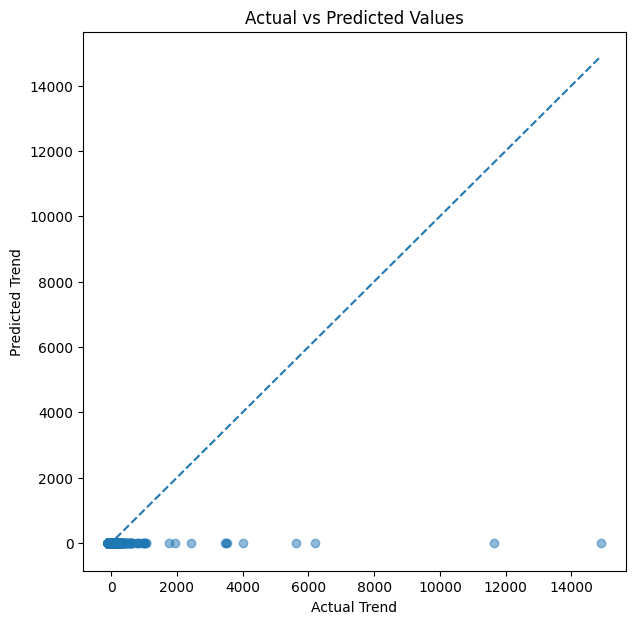

In [ ]:
import matplotlib.pyplot as plt

best_model = models[best_model_name]

predictions = best_model.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Trend")

plt.ylabel("Predicted Trend")

plt.title("Actual vs Predicted Values")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

### Scatter Plot

The scatter plot compares observed and predicted values for the selected baseline model.

Predictions remain concentrated around the mean value of the target, illustrating the limited predictive signal available in the current feature set.

This visualization is consistent with the quantitative evaluation presented in the model comparison table.

## 5. Limitations

*What this work cannot claim.*

## Limitations

This project is designed as a decision-support system rather than a causal analysis.

The model identifies content pages that appear to have higher optimization opportunity based on historical search intelligence signals. It cannot guarantee that refreshing a page will improve future rankings, clicks, or traffic.

Several limitations should be considered:

- The dataset represents a historical snapshot rather than a complete timeline.
- External factors such as Google algorithm updates, competitor activity, and seasonality are not fully represented.
- The model evaluates observed relationships rather than causal effects.
- Some variables contain missing values that were handled through median imputation.
- Client identifiers, domains, URLs, and private search queries were intentionally excluded to preserve privacy and reduce memorization.

The results should therefore be interpreted as directional evidence that supports content prioritization rather than guaranteed business outcomes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The recommendation table ranks content pages using the observed optimization opportunity framework developed in this study.

Although the evaluated predictive models did not outperform the baseline, the ranking still provides a structured decision-support view for prioritizing manual content reviews.

Each recommendation should be validated by SEO specialists before implementation.

In [ ]:
# Generate final ranked content recommendations

# Train final model
final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# Predict opportunity score
recommendations = model_df.copy()

recommendations["predicted_opportunity"] = final_model.predict(X)


# Create action labels
recommendations["recommended_action"] = np.where(
    recommendations["predicted_opportunity"] >=
    recommendations["predicted_opportunity"].quantile(0.80),
    "Refresh Immediately",
    np.where(
        recommendations["predicted_opportunity"] >=
        recommendations["predicted_opportunity"].median(),
        "Review",
        "Monitor"
    )
)


# Add reason codes
def assign_reason_code(row):

    if row["days_since_last_update"] > df["days_since_last_update"].quantile(0.75):
        return "Stale Content"

    elif (
        row["ctr"] < df["ctr"].quantile(0.25)
        and row["impressions_90d"] > df["impressions_90d"].median()
    ):
        return "Low CTR Opportunity"

    elif row["search_volume"] > df["search_volume"].quantile(0.75):
        return "High Search Demand"

    elif row["trend_pct"] < 0:
        return "Declining Trend"

    else:
        return "General Optimization Opportunity"


recommendations["reason_code"] = recommendations.apply(
    assign_reason_code,
    axis=1
)


# Rank highest opportunity first
recommendations = recommendations.sort_values(
    "predicted_opportunity",
    ascending=False
)


# Display Top 20
top_20 = recommendations.head(20)

display(
    top_20[
        [
            "predicted_opportunity",
            "recommended_action",
            "reason_code",
            "search_volume",
            "ctr",
            "avg_position",
            "days_since_last_update",
            "trend_pct"
        ]
    ]
)

,predicted_opportunity,recommended_action,reason_code,search_volume,ctr,avg_position,days_since_last_update,trend_pct
24695,30782.3260,Refresh Immediately,High Search Demand,70.0,0.00,75.5,20.0,44900.0
15405,18647.1330,Refresh Immediately,General Optimization Opportunity,0.0,0.01,85.8,20.0,27907.3
14549,17132.8960,Refresh Immediately,General Optimization Opportunity,10.0,0.08,2.1,20.0,26166.7
3561,14010.4105,Refresh Immediately,General Optimization Opportunity,0.0,0.00,13.1,8.0,21400.0
19697,10752.5125,Refresh Immediately,General Optimization Opportunity,10.0,0.16,6.4,20.0,17077.8
19968,10443.8425,Refresh Immediately,High Search Demand,880.0,0.00,75.5,22.0,175.6
24726,10111.6825,Refresh Immediately,High Search Demand,40.0,0.00,27.7,20.0,15825.0
19525,7266.4430,Refresh Immediately,High Search Demand,70.0,0.00,73.5,20.0,11250.0
1132,7097.3015,Refresh Immediately,General Optimization Opportunity,10.0,0.99,11.3,104.0,11266.7
6987,6368.3810,Refresh Immediately,High Search Demand,2900.0,0.00,2.2,20.0,-28.6


## Top 20 Ranked Content Recommendations

In [ ]:
print("Top 20 Ranked Content Recommendations")

top_20_recommendations = recommendations.head(20)

display(
    top_20_recommendations[
        [
            "predicted_opportunity",
            "recommended_action",
            "reason_code",
            "search_volume",
            "ctr",
            "avg_position",
            "days_since_last_update",
            "trend_pct"
        ]
    ]
)

Top 20 Ranked Content Recommendations


,predicted_opportunity,recommended_action,reason_code,search_volume,ctr,avg_position,days_since_last_update,trend_pct
24695,30782.3260,Refresh Immediately,High Search Demand,70.0,0.00,75.5,20.0,44900.0
15405,18647.1330,Refresh Immediately,General Optimization Opportunity,0.0,0.01,85.8,20.0,27907.3
14549,17132.8960,Refresh Immediately,General Optimization Opportunity,10.0,0.08,2.1,20.0,26166.7
3561,14010.4105,Refresh Immediately,General Optimization Opportunity,0.0,0.00,13.1,8.0,21400.0
19697,10752.5125,Refresh Immediately,General Optimization Opportunity,10.0,0.16,6.4,20.0,17077.8
19968,10443.8425,Refresh Immediately,High Search Demand,880.0,0.00,75.5,22.0,175.6
24726,10111.6825,Refresh Immediately,High Search Demand,40.0,0.00,27.7,20.0,15825.0
19525,7266.4430,Refresh Immediately,High Search Demand,70.0,0.00,73.5,20.0,11250.0
1132,7097.3015,Refresh Immediately,General Optimization Opportunity,10.0,0.99,11.3,104.0,11266.7
6987,6368.3810,Refresh Immediately,High Search Demand,2900.0,0.00,2.2,20.0,-28.6


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts

The following outputs were generated during this research project and are suitable for inclusion in the deployed research paper.

Artifacts include:

- Dataset summary table
- Missing value summary
- Model comparison table
- Actual vs Predicted scatter plot
- Top 20 ranked recommendations
- Baseline versus machine learning comparison

These figures improve transparency and make the analysis reproducible.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nFeature Matrix Shape:", X.shape)

print("\nTop Model Performance")

display(results_df)

print("\nTop Ranked Recommendations")

display(recommendations.head(20))

Dataset Shape: (30000, 44)

Feature Matrix Shape: (26612, 15)

Top Model Performance


,Model,MAE,RMSE,R²
0,Dummy Regressor,64.1583,315.9668,-0.0001
1,Linear Regression,65.8695,317.0327,-0.0068
2,Random Forest,71.7958,351.5542,-0.2380



Top Ranked Recommendations


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,sessions_90d,engaged_sessions_90d,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,predicted_opportunity,recommended_action,reason_code
24695,70.0,0.01,0.00,2844.0,19232.0,460.0,0.0,3.0,0.0,20.0,0.00,75.5,0.00,75.00,0.0,44900.0,30782.3260,Refresh Immediately,High Search Demand
15405,0.0,0.00,0.00,3530.0,22134.0,214047.0,12.0,147.0,5.0,20.0,0.01,85.8,3.40,3.61,0.0,27907.3,18647.1330,Refresh Immediately,General Optimization Opportunity
14549,10.0,1.00,1.60,2835.0,20955.0,2377.0,2.0,1.0,0.0,20.0,0.08,2.1,0.00,0.00,0.0,26166.7,17132.8960,Refresh Immediately,General Optimization Opportunity
3561,0.0,0.00,0.00,2917.0,19893.0,216.0,0.0,16.0,1.0,8.0,0.00,13.1,6.25,6.25,0.0,21400.0,14010.4105,Refresh Immediately,General Optimization Opportunity
19697,10.0,0.24,0.00,2637.0,19088.0,3156.0,5.0,7.0,1.0,20.0,0.16,6.4,14.29,14.29,0.0,17077.8,10752.5125,Refresh Immediately,General Optimization Opportunity
19968,880.0,0.03,1.07,2877.0,19116.0,2031.0,0.0,3.0,0.0,22.0,0.00,75.5,0.00,0.00,0.0,175.6,10443.8425,Refresh Immediately,High Search Demand
24726,40.0,0.49,1.38,2451.0,17207.0,1605.0,0.0,2.0,0.0,20.0,0.00,27.7,0.00,0.00,0.0,15825.0,10111.6825,Refresh Immediately,High Search Demand
19525,70.0,0.01,0.00,3074.0,20405.0,248.0,0.0,7.0,0.0,20.0,0.00,73.5,0.00,27.27,0.0,11250.0,7266.4430,Refresh Immediately,High Search Demand
1132,10.0,0.82,0.00,1808.0,11699.0,405.0,4.0,10.0,0.0,104.0,0.99,11.3,0.00,27.27,0.0,11266.7,7097.3015,Refresh Immediately,General Optimization Opportunity
6987,2900.0,1.00,1.60,2857.0,17073.0,80.0,0.0,9.0,0.0,20.0,0.00,2.2,0.00,12.50,0.0,-28.6,6368.3810,Refresh Immediately,High Search Demand


In [ ]:
recommendations.to_csv(
    "work/outputs/final_ranked_recommendations.csv",
    index=False
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.